In [32]:
from sympy import primerange
import json

# Generate primes up to a large limit
n = 10**8
primes = list(primerange(1, n))

# Save primes to JSON file
with open('primes.json', 'w') as f:
    json.dump(primes, f)

print(f"Generated {len(primes)} primes up to {n}.")


Generated 5761455 primes up to 100000000.


In [36]:
# Read from the dataset instead
# https://www.kaggle.com/datasets/wellington36/prime-number

import json

# Read the file and process it into a list of integers
with open('primes_1bi.txt', 'r') as f:
    primes = [int(line.strip()) for line in f]

# Save the primes list to a JSON file
with open('primes.json', 'w') as f:
    json.dump(primes, f)

print(f"Saved {len(primes)} primes to primes.json.")


Saved 50847534 primes to primes.json.


In [37]:
import json

# Load primes from JSON file
with open('primes.json', 'r') as f:
    primes = json.load(f)

# Compute prime gaps
gaps = [primes[i+1] - primes[i] for i in range(len(primes) - 1)]

# Save gaps to JSON file
with open('prime_gaps.json', 'w') as f:
    json.dump(gaps, f)

print(f"Computed {len(gaps)} prime gaps.")


Computed 50847533 prime gaps.


In [38]:
# Find twin primes
twin_primes = [(primes[i], primes[i+1]) for i in range(len(primes) - 1) if primes[i+1] - primes[i] == 2]

# Save twin primes to JSON file
with open('twin_primes.json', 'w') as f:
    json.dump(twin_primes, f)

print(f"Found {len(twin_primes)} twin primes.")


Found 3424506 twin primes.


In [39]:
import numpy as np
import json

# Load primes
with open('primes.json', 'r') as f:
    primes = json.load(f)

# Convert primes to a NumPy array
primes = np.array(primes)

# Compute S(n) and ΔS/Δn
S = np.cumsum(np.log(primes))
delta_S = np.diff(S)  # Approximation of ΔS/Δn
n_values = primes[:-1]  # Corresponding n values for ΔS/Δn

# Save results to JSON
results = {'n': n_values.tolist(), 'S(n)': S.tolist(), 'ΔS/Δn': delta_S.tolist()}
with open('imax_analysis.json', 'w') as f:
    json.dump(results, f)

print("Saved I_max analysis.")


Saved I_max analysis.


In [40]:
import json

# Load data
with open('imax_analysis.json', 'r') as f:
    data = json.load(f)

# Extract values
n_values = data['n']
S_values = data['S(n)']
delta_S_values = data['ΔS/Δn']

print(f"Loaded {len(n_values)} prime data points.")
print(f"Loaded {len(S_values)} S(n) points.")
print(f"Loaded {len(delta_S_values)} ΔS/Δn points.")

Loaded 50847533 prime data points.
Loaded 50847534 S(n) points.
Loaded 50847533 ΔS/Δn points.


In [41]:
# Align dimensions
S_values = S_values[:len(n_values)]  # Trim S(n) to match n
# Verify lengths
assert len(n_values) == len(S_values), "Mismatch in lengths of n and S(n)"
assert len(n_values) == len(delta_S_values), "Mismatch in lengths of n and ΔS/Δn"

print(f"Aligned lengths: {len(n_values)}")


Aligned lengths: 50847533


In [42]:
import numpy as np
import json

# Assume n_values, S_values, delta_S_values are already defined as lists or arrays

# Ensure all inputs are NumPy arrays
n_values = np.array(n_values)
S_values = np.array(S_values)
delta_S_values = np.array(delta_S_values)

# Align all arrays to the shortest length
aligned_length = min(len(n_values), len(S_values), len(delta_S_values))

n_values = n_values[:aligned_length]
S_values = S_values[:aligned_length]
delta_S_values = delta_S_values[:aligned_length]

# Compute I_max
imax_values = S_values * delta_S_values

# Save results
results = {'n': n_values.tolist(), 'I_max': imax_values.tolist()}
with open('imax_results.json', 'w') as f:
    json.dump(results, f)

print(f"Computed I_max for {len(imax_values)} primes.")


Computed I_max for 50847533 primes.


/Users/nicholasking/code/physics/ComplexityEfficiency/env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


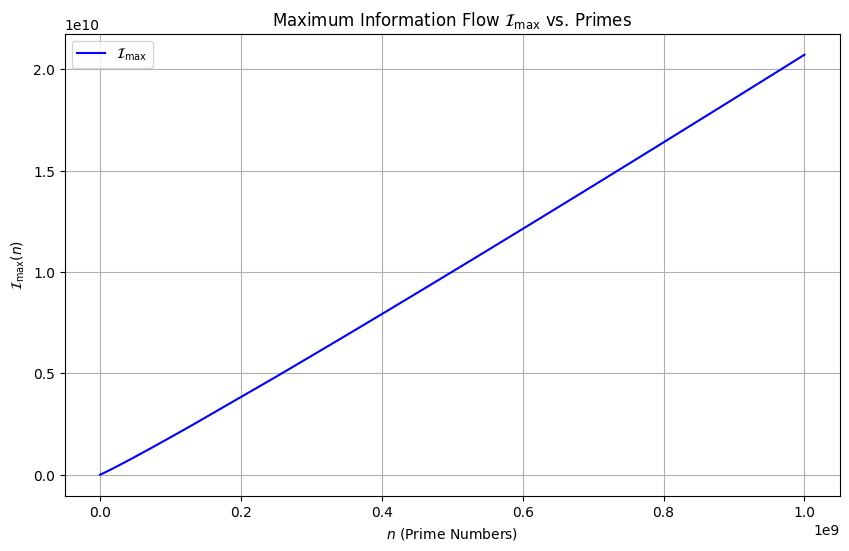

In [43]:
import matplotlib.pyplot as plt

# Plot I_max
plt.figure(figsize=(10, 6))
plt.plot(n_values, imax_values, label='$\mathcal{I}_{\\text{max}}$', color='blue')
plt.xlabel('$n$ (Prime Numbers)')
plt.ylabel('$\mathcal{I}_{\\text{max}}(n)$')
plt.title('Maximum Information Flow $\mathcal{I}_{\\text{max}}$ vs. Primes')
plt.legend()
plt.grid()
plt.show()


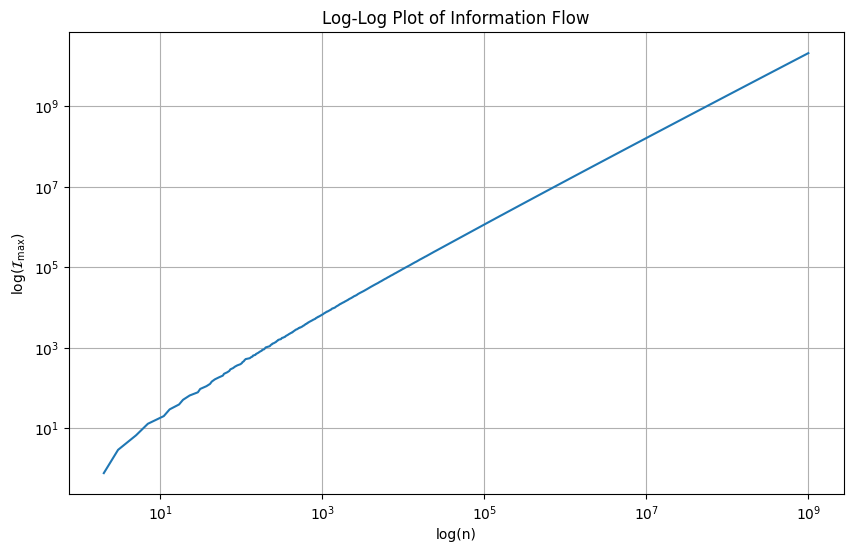

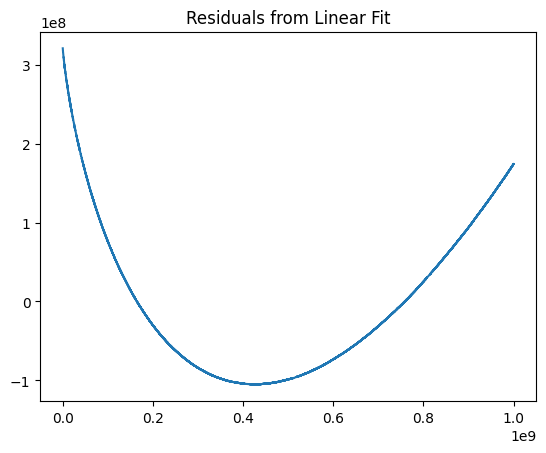

In [44]:
# Log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(n_values, imax_values, label='$\mathcal{I}_{\\text{max}}$')
plt.xlabel('log(n)')
plt.ylabel('log($\mathcal{I}_{\\text{max}}$)')
plt.title('Log-Log Plot of Information Flow')
plt.grid(True)
plt.show()

# Examine residuals
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(n_values, imax_values)
residuals = imax_values - (slope * n_values + intercept)
plt.plot(n_values, residuals)
plt.title('Residuals from Linear Fit')
plt.show()

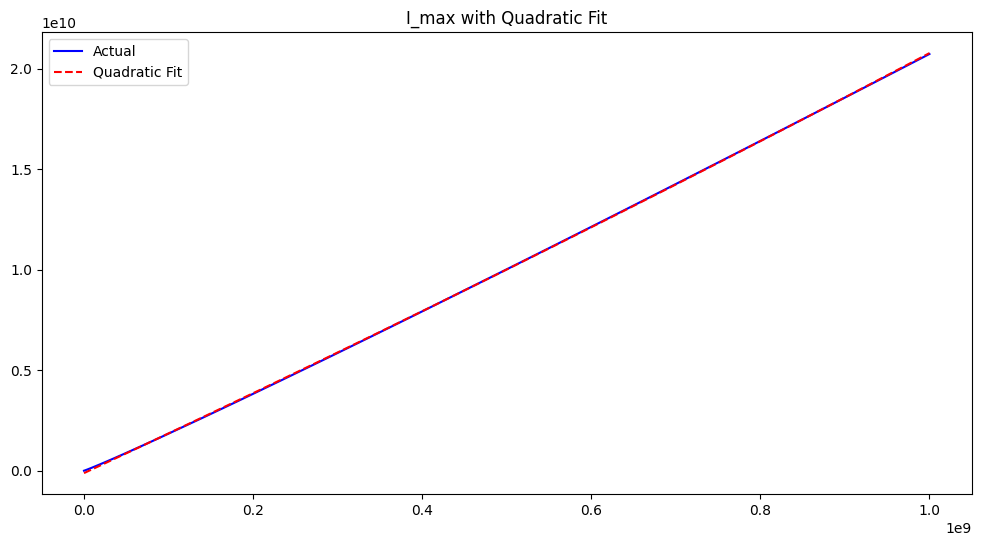

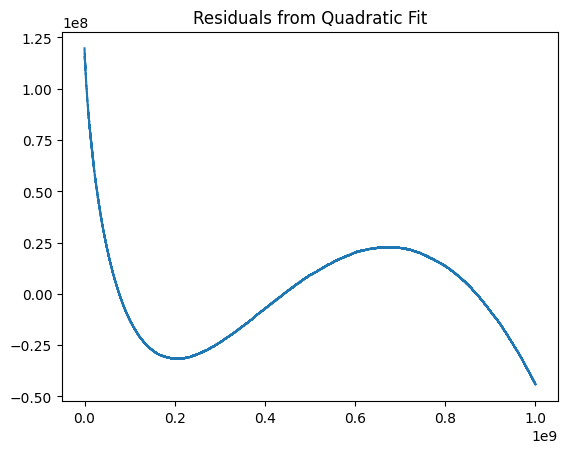

In [45]:
# Fit a quadratic function
from numpy.polynomial.polynomial import polyfit
coeffs = polyfit(n_values, imax_values, 2)
quad_fit = coeffs[0] + coeffs[1]*n_values + coeffs[2]*n_values**2

# Plot original and fit
plt.figure(figsize=(12,6))
plt.plot(n_values, imax_values, 'b-', label='Actual')
plt.plot(n_values, quad_fit, 'r--', label='Quadratic Fit')
plt.title('I_max with Quadratic Fit')
plt.legend()
plt.show()

# Look at residuals from quadratic fit
quad_residuals = imax_values - quad_fit
plt.plot(n_values, quad_residuals)
plt.title('Residuals from Quadratic Fit')
plt.show()

In [23]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 2.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 2.9 MB/s eta 0:00:003.0 MB/s eta 0:00:01

[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [46]:
# Calculate fit accuracy
from sklearn.metrics import r2_score
r2 = r2_score(imax_values, quad_fit)
print(f"R² score: {r2}")

# Look at percentage deviation
percent_diff = 100 * (quad_fit - imax_values) / imax_values
print(f"Mean percentage difference: {np.mean(abs(percent_diff))}%")

R² score: 0.9999829229919338
Mean percentage difference: 538.6786751497258%


/Users/nicholasking/code/physics/ComplexityEfficiency/env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


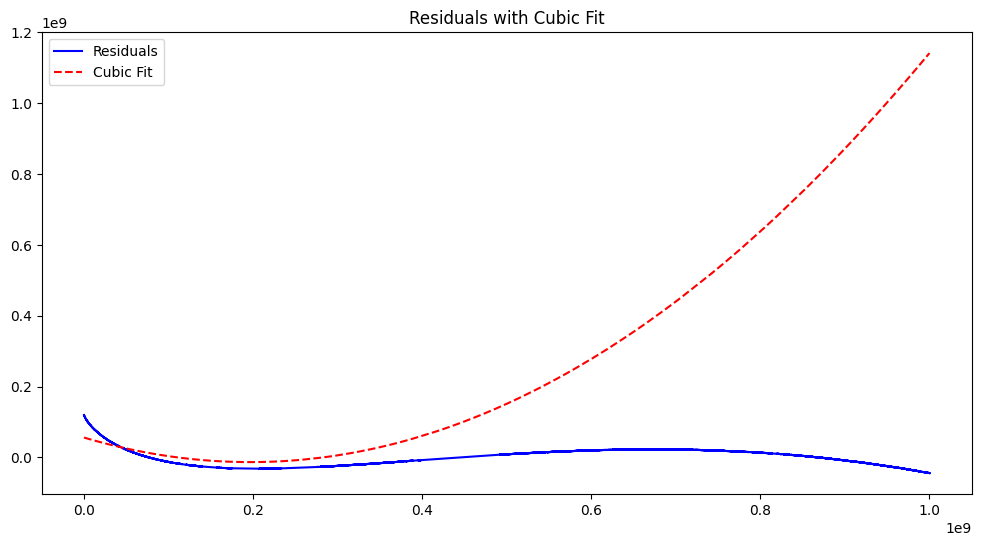

In [48]:
# Fit cubic to residuals
cubic_coeffs = polyfit(n_values, quad_residuals, 3)
cubic_fit = cubic_coeffs[0] + cubic_coeffs[1]*n_values + cubic_coeffs[2]*n_values**2 + cubic_coeffs[3]*n_values**3

# Plot original residuals and cubic fit
plt.figure(figsize=(12,6))
plt.plot(n_values, quad_residuals, 'b-', label='Residuals')
plt.plot(n_values, cubic_fit, 'r--', label='Cubic Fit')
plt.title('Residuals with Cubic Fit')
plt.legend()
plt.show()

Mean absolute difference: 20060980.87745871


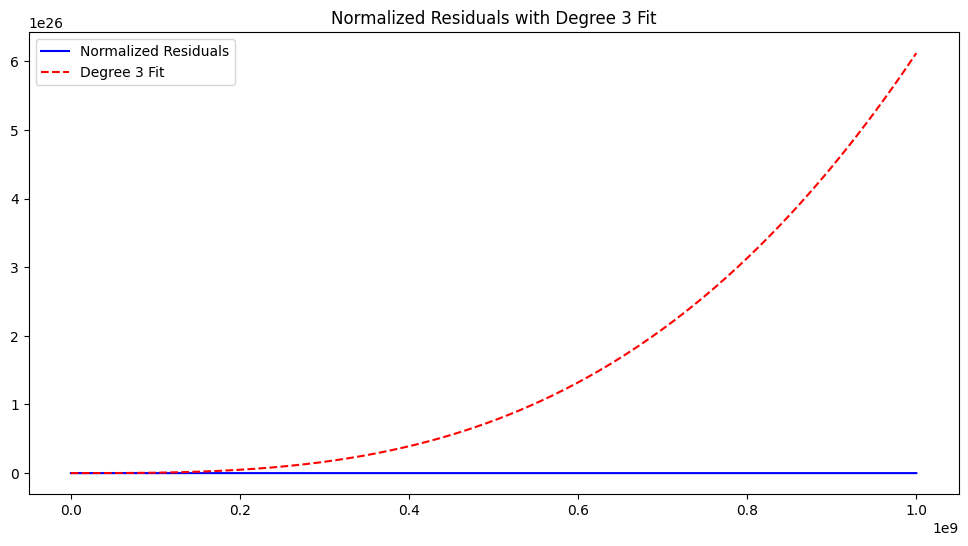

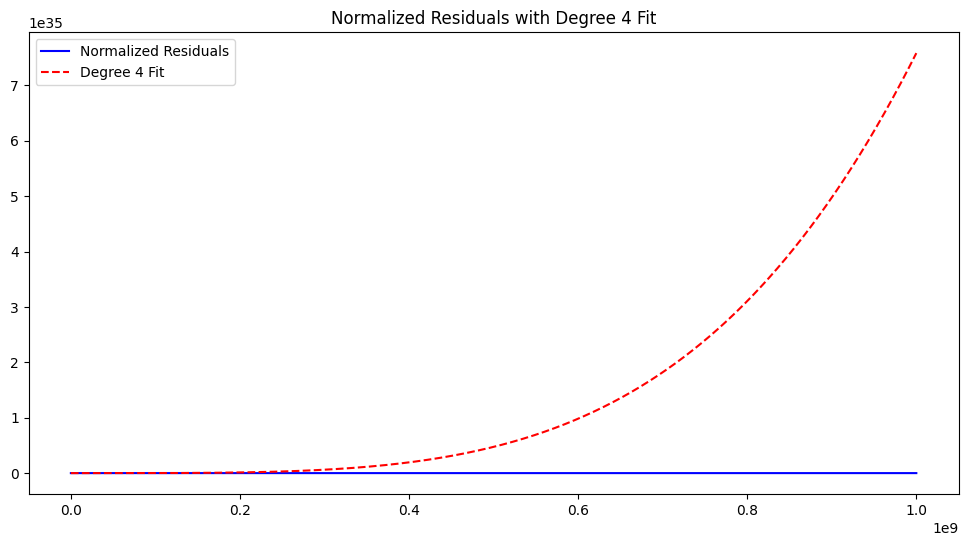

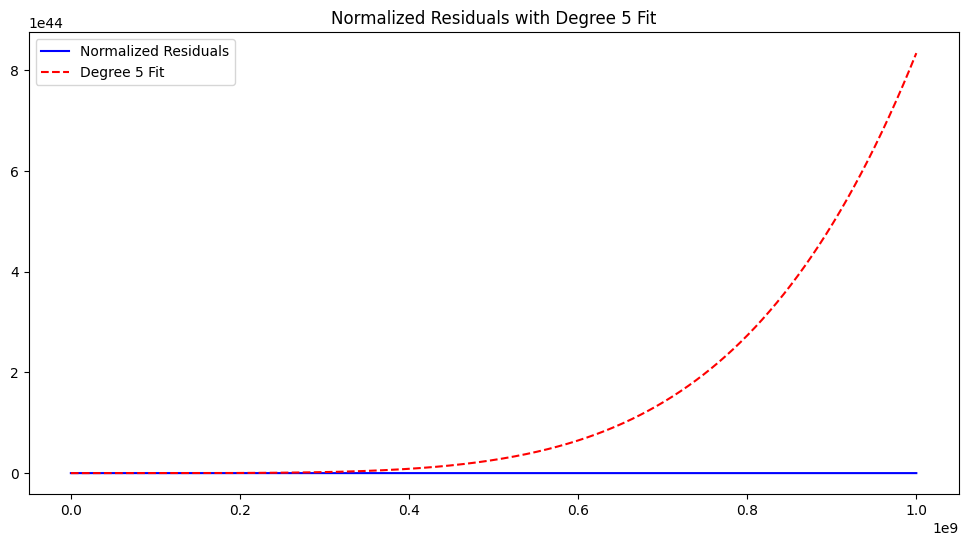

In [49]:
# Look at absolute differences instead of percentages
abs_diff = np.abs(quad_fit - imax_values)
print(f"Mean absolute difference: {np.mean(abs_diff)}")

# Maybe normalize the residuals first
normalized_residuals = (quad_residuals - np.min(quad_residuals)) / (np.max(quad_residuals) - np.min(quad_residuals))

# Try polynomial fits of different orders
for degree in [3, 4, 5]:
    coeffs = polyfit(n_values, normalized_residuals, degree)
    fit = np.polyval(coeffs, n_values)
    plt.figure(figsize=(12,6))
    plt.plot(n_values, normalized_residuals, 'b-', label='Normalized Residuals')
    plt.plot(n_values, fit, 'r--', label=f'Degree {degree} Fit')
    plt.title(f'Normalized Residuals with Degree {degree} Fit')
    plt.legend()
    plt.show()

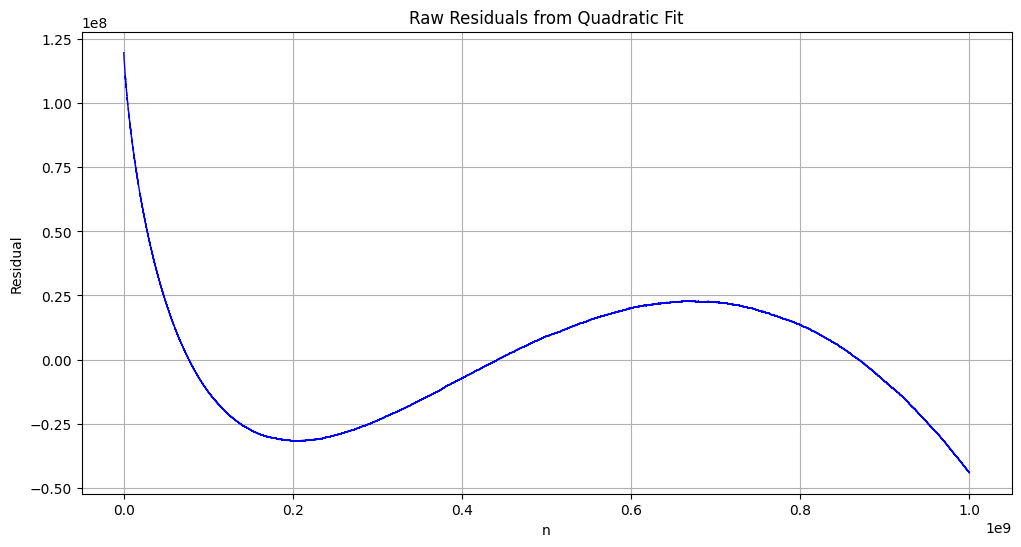

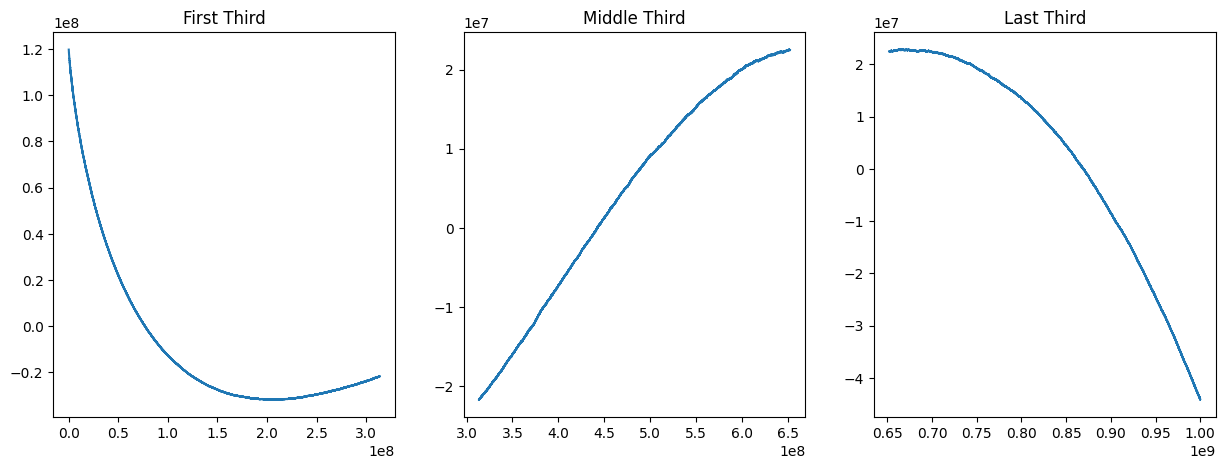

In [50]:
# Just plot the raw residuals again, cleaned up
plt.figure(figsize=(12,6))
plt.plot(n_values, quad_residuals, 'b-', linewidth=1)
plt.title('Raw Residuals from Quadratic Fit')
plt.xlabel('n')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

# Maybe look at different sections
# Split into thirds and plot separately
split1 = len(n_values)//3
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(n_values[:split1], quad_residuals[:split1])
plt.title('First Third')
plt.subplot(132)
plt.plot(n_values[split1:2*split1], quad_residuals[split1:2*split1])
plt.title('Middle Third')
plt.subplot(133)
plt.plot(n_values[2*split1:], quad_residuals[2*split1:])
plt.title('Last Third')
plt.show()

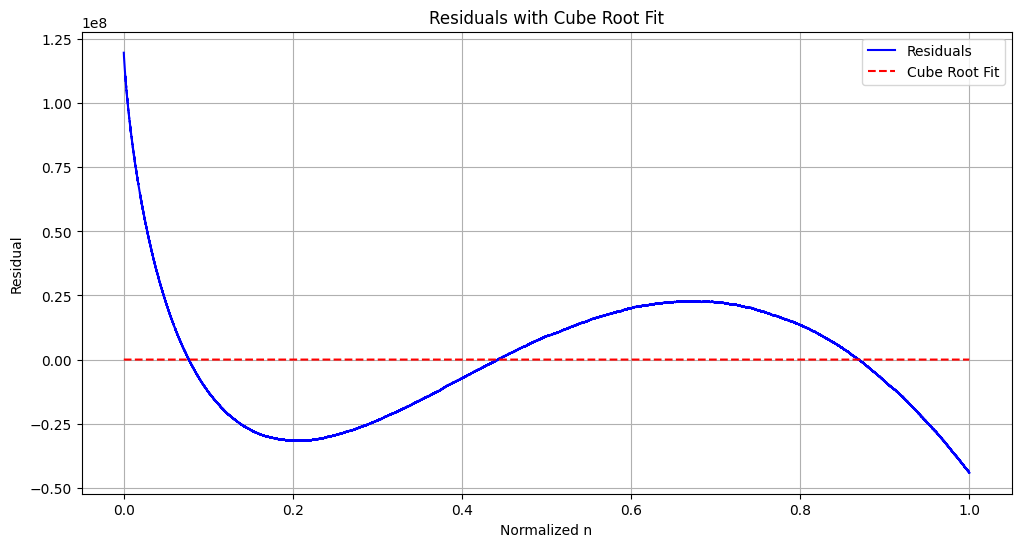

Fit parameters: a=-248.84332163914175, b=5.104052775509166, c=-87.33999163779724


In [51]:
# Try cube root fit to residuals
def cube_root_fit(x, a, b, c):
    return a * np.cbrt(x - b) + c

from scipy.optimize import curve_fit

# Normalize x values to 0-1 range for better fitting
x_norm = (n_values - np.min(n_values)) / (np.max(n_values) - np.min(n_values))

try:
    # Fit cube root function to residuals
    popt, _ = curve_fit(cube_root_fit, x_norm, quad_residuals)
    
    # Plot original residuals and cube root fit
    plt.figure(figsize=(12,6))
    plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
    plt.plot(x_norm, cube_root_fit(x_norm, *popt), 'r--', label='Cube Root Fit')
    plt.title('Residuals with Cube Root Fit')
    plt.xlabel('Normalized n')
    plt.ylabel('Residual')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Fit parameters: a={popt[0]}, b={popt[1]}, c={popt[2]}")
except:
    print("Fitting failed, might need to adjust initial parameters")

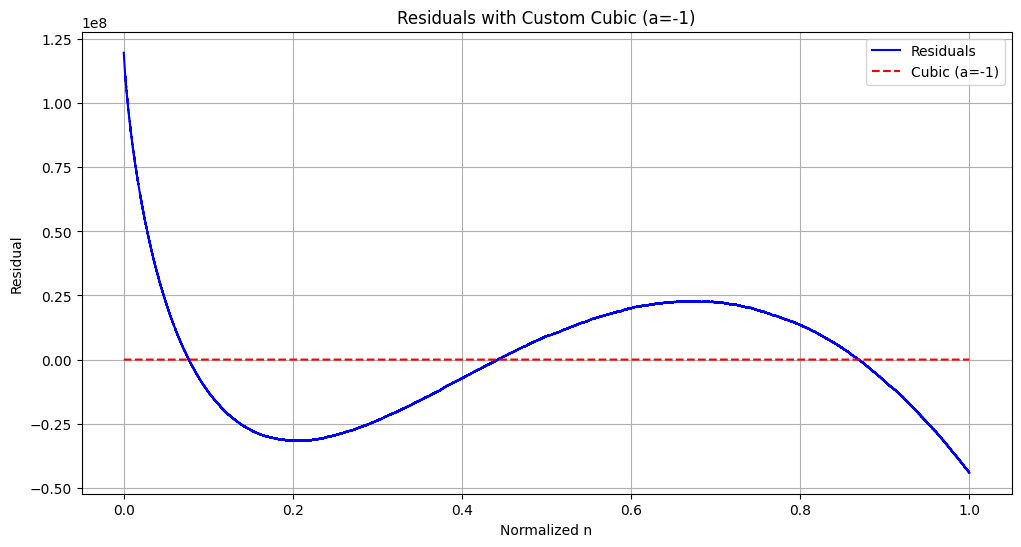

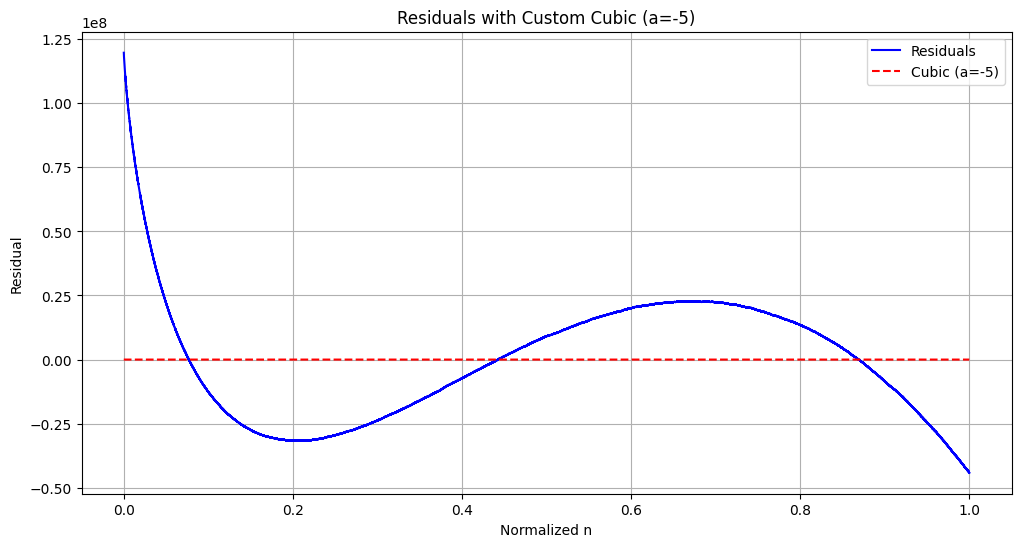

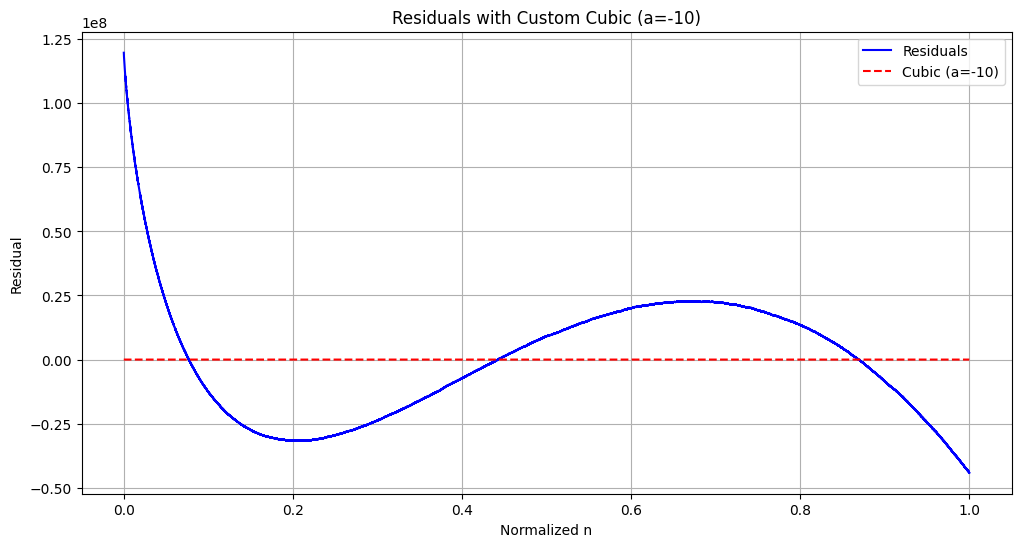

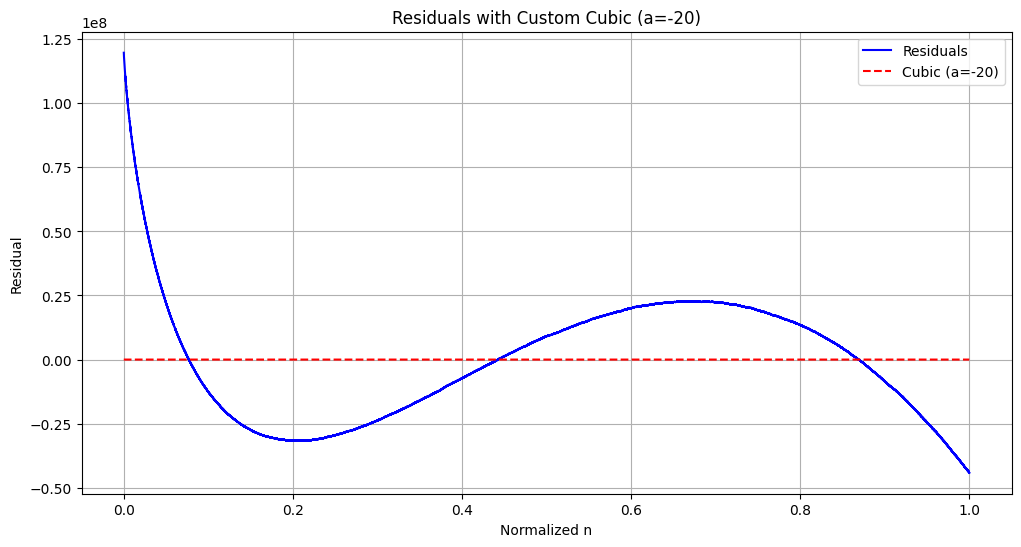

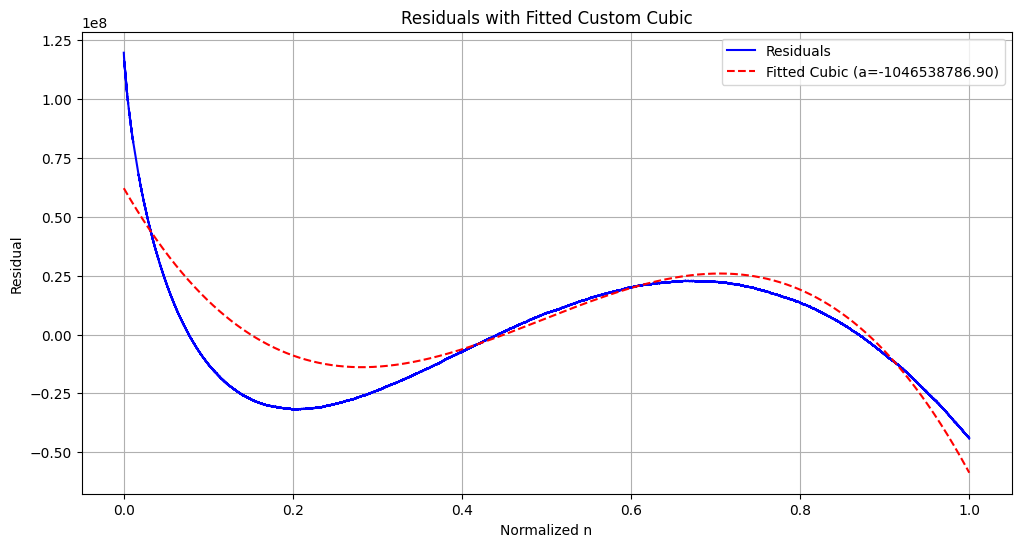

In [52]:
# Create cubic function with specified roots
def custom_cubic(x, a):
    # Roots at 0.15, 0.45, and 0.88
    return a * (x - 0.15) * (x - 0.45) * (x - 0.88)

# Try different values of 'a' (negative to trend down)
for a in [-1, -5, -10, -20]:
    plt.figure(figsize=(12,6))
    plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
    plt.plot(x_norm, custom_cubic(x_norm, a), 'r--', label=f'Cubic (a={a})')
    plt.title(f'Residuals with Custom Cubic (a={a})')
    plt.xlabel('Normalized n')
    plt.ylabel('Residual')
    plt.legend()
    plt.grid(True)
    plt.show()

# Or let's try fitting 'a' automatically
try:
    def fit_func(x, a):
        return custom_cubic(x, a)
    
    popt, _ = curve_fit(fit_func, x_norm, quad_residuals)
    a_fit = popt[0]
    
    plt.figure(figsize=(12,6))
    plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
    plt.plot(x_norm, custom_cubic(x_norm, a_fit), 'r--', label=f'Fitted Cubic (a={a_fit:.2f})')
    plt.title('Residuals with Fitted Custom Cubic')
    plt.xlabel('Normalized n')
    plt.ylabel('Residual')
    plt.legend()
    plt.grid(True)
    plt.show()
except:
    print("Fitting failed, might need to adjust approach")

Zero crossings at x = [0.07690769 0.44224422 0.86908691]


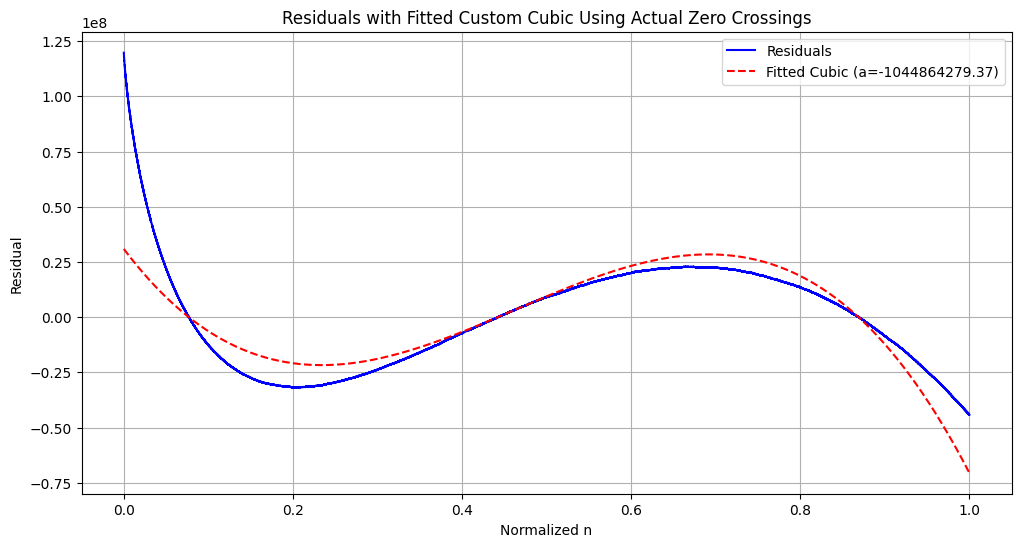

In [53]:
# Find where residuals cross zero
# First interpolate to get more precise crossings
from scipy.interpolate import interp1d

f = interp1d(x_norm, quad_residuals, kind='linear')
x_dense = np.linspace(np.min(x_norm), np.max(x_norm), 10000)
y_dense = f(x_dense)

# Find zero crossings
zero_crossings = x_dense[np.where(np.diff(np.signbit(y_dense)))[0]]
print("Zero crossings at x =", zero_crossings)

# Now create cubic with actual zero crossings
def custom_cubic_actual(x, a):
    return a * (x - zero_crossings[0]) * (x - zero_crossings[1]) * (x - zero_crossings[2])

# Fit with actual zero crossings
popt, _ = curve_fit(lambda x, a: custom_cubic_actual(x, a), x_norm, quad_residuals)
a_fit = popt[0]

plt.figure(figsize=(12,6))
plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
plt.plot(x_norm, custom_cubic_actual(x_norm, a_fit), 'r--', 
         label=f'Fitted Cubic (a={a_fit:.2f})')
plt.title('Residuals with Fitted Custom Cubic Using Actual Zero Crossings')
plt.xlabel('Normalized n')
plt.ylabel('Residual')
plt.legend()
plt.grid(True)
plt.show()

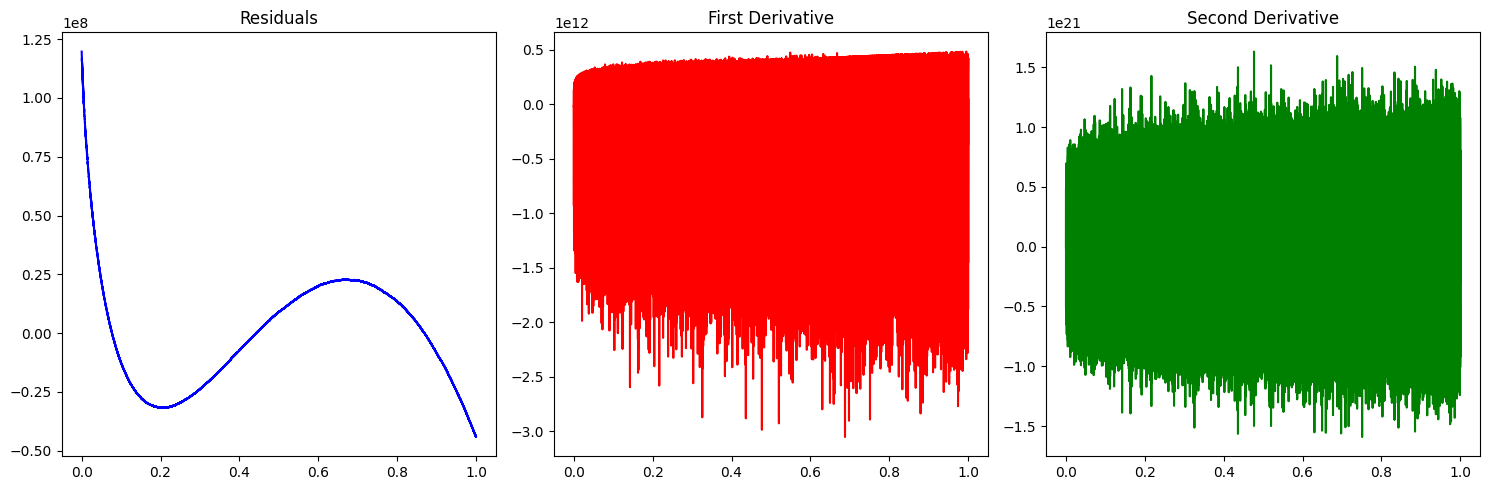

In [54]:
# Calculate numerical derivatives of residuals
dx = x_norm[1] - x_norm[0]  # spacing
d_residuals = np.gradient(quad_residuals, dx)
d2_residuals = np.gradient(d_residuals, dx)

# Plot residuals and their derivatives
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
plt.title('Residuals')
plt.subplot(132)
plt.plot(x_norm, d_residuals, 'r-', label='First Derivative')
plt.title('First Derivative')
plt.subplot(133)
plt.plot(x_norm, d2_residuals, 'g-', label='Second Derivative')
plt.title('Second Derivative')
plt.tight_layout()
plt.show()

In [55]:
# Sample points evenly across the range
num_samples = 75  # or whatever number you prefer
indices = np.linspace(0, len(x_norm)-1, num_samples, dtype=int)

print("x_norm, quad_residuals:")
for i in indices:
    print(f"{x_norm[i]:.6f}, {quad_residuals[i]:.6f}")

# Maybe also print first/second derivatives at these points
print("\nWith derivatives:")
for i in indices:
    print(f"x: {x_norm[i]:.6f}, residual: {quad_residuals[i]:.6f}, d1: {d_residuals[i]:.6f}, d2: {d2_residuals[i]:.6f}")

x_norm, quad_residuals:
0.000000, 119724295.947088
0.010364, 83637811.898081
0.021747, 59896416.927601
0.033514, 41570363.277573
0.045532, 26804855.784293
0.057736, 14685376.542651
0.070086, 4709493.479000
0.082557, -3518078.722006
0.095135, -10354432.760528
0.107799, -15848426.462424
0.120552, -20436705.674932
0.133371, -23984873.813191
0.146257, -26731660.376667
0.159212, -28914494.339667
0.172211, -30255633.762329
0.185264, -31101633.845879
0.198378, -31682762.689125
0.211526, -31605187.953125
0.224720, -31211477.669211
0.237953, -30465718.603761
0.251222, -29384496.588446
0.264533, -28132132.548890
0.277874, -26578765.073606
0.291255, -24975377.551168
0.304663, -23111099.111811
0.318096, -21013648.150647
0.331571, -19041951.024417
0.345062, -16755690.812389
0.358588, -14552122.495754
0.372140, -12316193.088454
0.385701, -9713662.624434
0.399305, -7471741.926173
0.412923, -5067587.969854
0.426564, -2662936.250133
0.440235, -460659.940748
0.453916, 1920031.851917
0.467620, 4208171.68

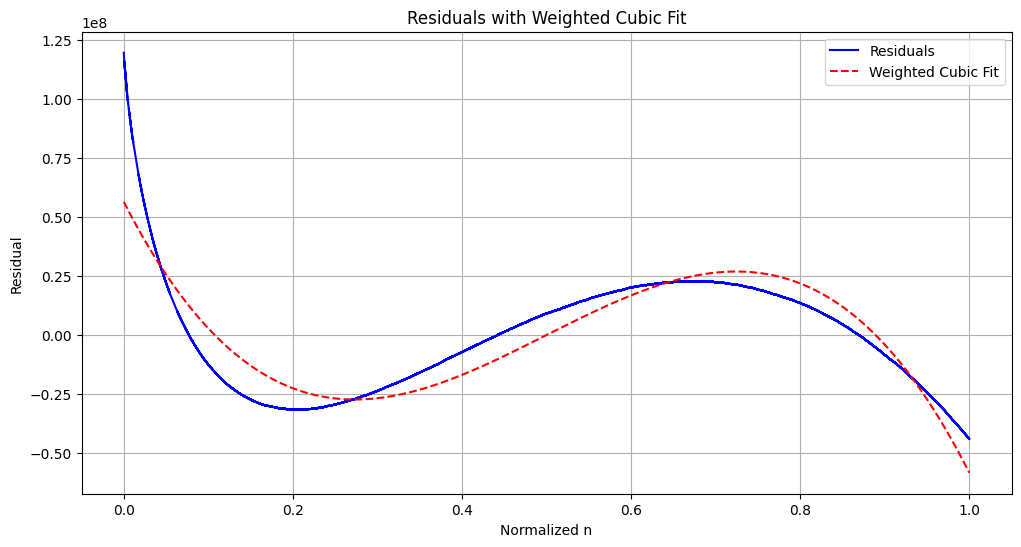

Coefficients: a=-1181743243.842885, b=1768796674.9085302, c=-701983729.8979778, d=56435331.56043034


In [56]:
# Try weighted cubic fit
# Give more weight to the turning points and zero crossings
def weighted_cubic(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

# Create weights
weights = np.ones_like(x_norm)
# Increase weights near our known important points
for point in [0.077, 0.44, 0.87]:  # zero crossings
    weights += np.exp(-(x_norm - point)**2 / 0.01)  # gaussian around points

# Fit with weights
from scipy.optimize import curve_fit
popt, _ = curve_fit(weighted_cubic, x_norm, quad_residuals, sigma=weights)

# Plot result
plt.figure(figsize=(12,6))
plt.plot(x_norm, quad_residuals, 'b-', label='Residuals')
plt.plot(x_norm, weighted_cubic(x_norm, *popt), 'r--', label='Weighted Cubic Fit')
plt.title('Residuals with Weighted Cubic Fit')
plt.xlabel('Normalized n')
plt.ylabel('Residual')
plt.legend()
plt.grid(True)
plt.show()

print(f"Coefficients: a={popt[0]}, b={popt[1]}, c={popt[2]}, d={popt[3]}")


In [ ]:
import numpy as np
from sympy import li as sympy_li

# Compute Li(x) for n_values using SymPy
Li_values = np.array([sympy_li(n) for n in n_values], dtype=np.float64)

# Compare Li(x) with I_max
Li_comparison = Li_values - imax_values

print("Computed logarithmic integral using SymPy and compared with I_max.")

In [60]:
# Approximation for Li(x)
Li_approx = n_values / np.log(n_values)

# Compare approximation with I_max
Li_comparison = Li_approx - imax_values

print("Computed approximate logarithmic integral and compared with I_max.")


Computed approximate logarithmic integral and compared with I_max.


In [61]:
Li_comparison

array([ 2.12389007e+00, -1.53007940e-01, -3.51174983e+00, ...,
       -2.06743667e+10, -2.06743671e+10, -2.06743675e+10],
      shape=(50847533,))

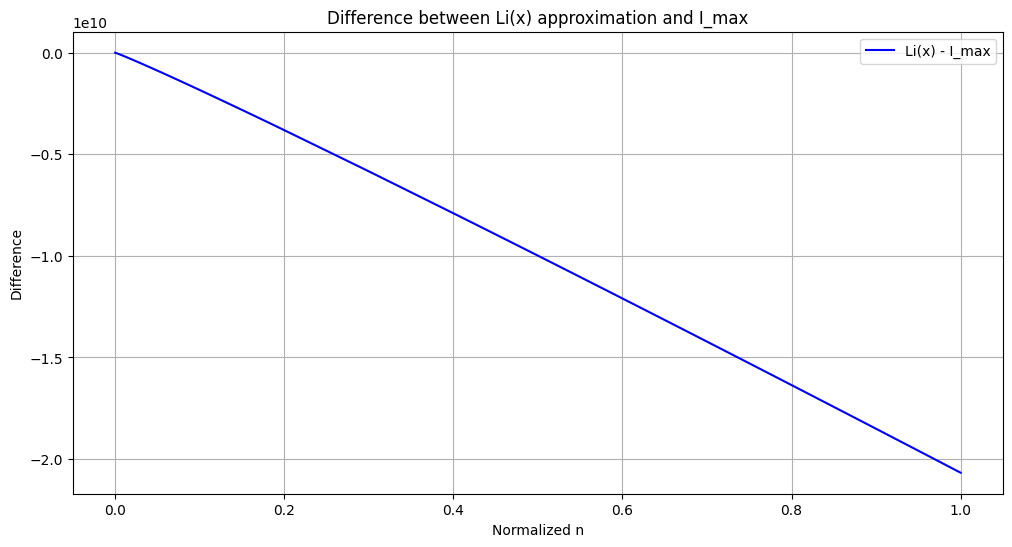

Mean difference: -9808617959.41134
Std deviation: 6066579098.166318


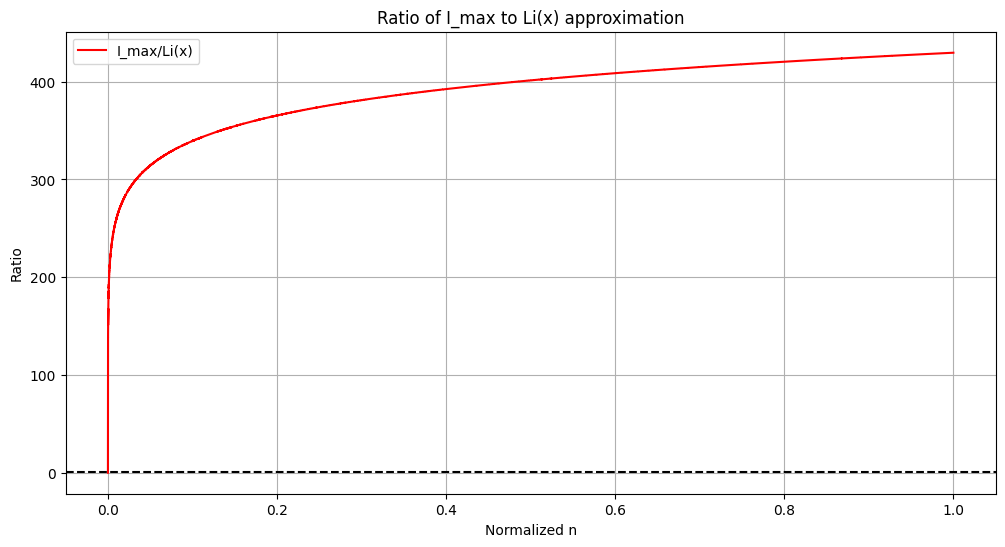

In [62]:
# Plot the comparison
plt.figure(figsize=(12,6))
plt.plot(x_norm, Li_comparison, 'b-', label='Li(x) - I_max')
plt.title('Difference between Li(x) approximation and I_max')
plt.xlabel('Normalized n')
plt.ylabel('Difference')
plt.grid(True)
plt.legend()
plt.show()

# Look at key statistics
print(f"Mean difference: {np.mean(Li_comparison)}")
print(f"Std deviation: {np.std(Li_comparison)}")

# Look at ratio
ratio = imax_values / Li_approx
plt.figure(figsize=(12,6))
plt.plot(x_norm, ratio, 'r-', label='I_max/Li(x)')
plt.title('Ratio of I_max to Li(x) approximation')
plt.xlabel('Normalized n')
plt.ylabel('Ratio')
plt.axhline(y=1, color='k', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

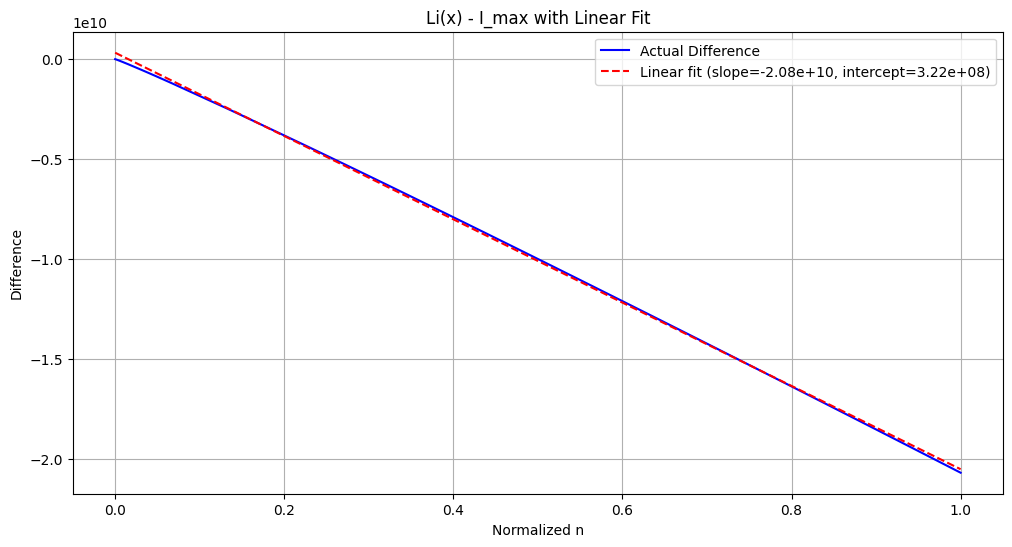

R² for linear fit: 0.9997324861053816


In [63]:
# Linear fit to difference
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(x_norm, Li_comparison)

plt.figure(figsize=(12,6))
plt.plot(x_norm, Li_comparison, 'b-', label='Actual Difference')
plt.plot(x_norm, slope*x_norm + intercept, 'r--', 
         label=f'Linear fit (slope={slope:.2e}, intercept={intercept:.2e})')
plt.title('Li(x) - I_max with Linear Fit')
plt.xlabel('Normalized n')
plt.ylabel('Difference')
plt.grid(True)
plt.legend()
plt.show()

print(f"R² for linear fit: {r_value**2}")

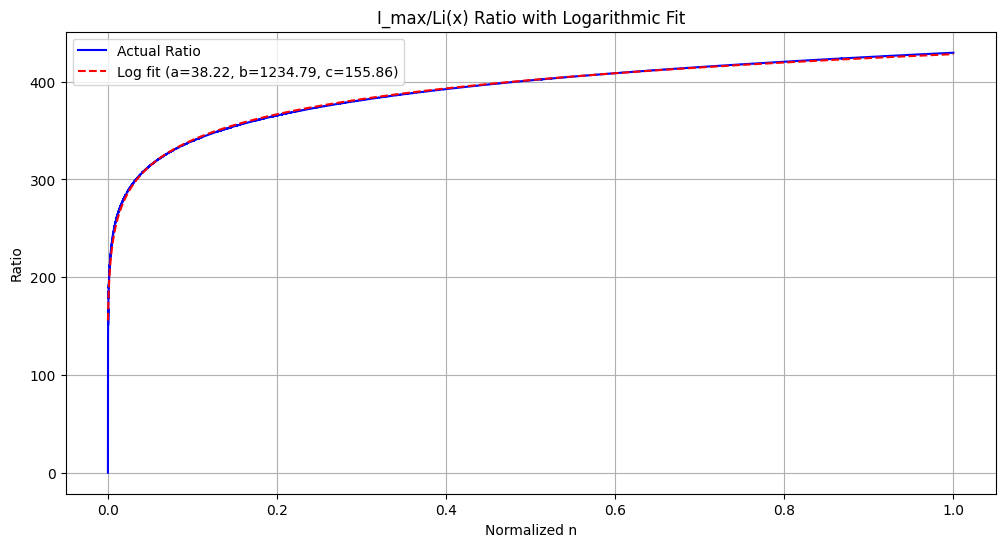

In [64]:
# Try logarithmic or power law fit
def log_func(x, a, b, c):
    return a * np.log(b*x + 1) + c

from scipy.optimize import curve_fit
popt, _ = curve_fit(log_func, x_norm, ratio)

plt.figure(figsize=(12,6))
plt.plot(x_norm, ratio, 'b-', label='Actual Ratio')
plt.plot(x_norm, log_func(x_norm, *popt), 'r--', 
         label=f'Log fit (a={popt[0]:.2f}, b={popt[1]:.2f}, c={popt[2]:.2f})')
plt.title('I_max/Li(x) Ratio with Logarithmic Fit')
plt.xlabel('Normalized n')
plt.ylabel('Ratio')
plt.grid(True)
plt.legend()
plt.show()

In [65]:
# For linear fit of difference
slope, intercept, r_value, p_value, std_err = linregress(x_norm, Li_comparison)
print("Linear Fit (Li(x) - I_max):")
print(f"Slope: {slope:.6e}")
print(f"Intercept: {intercept:.6e}")
print(f"R²: {r_value**2:.10f}")
print(f"Standard Error: {std_err:.6e}")

# For log fit of ratio
print("\nLogarithmic Fit (I_max/Li(x)):")
print(f"a (scale): {popt[0]:.6f}")
print(f"b (rate): {popt[1]:.6f}")
print(f"c (offset): {popt[2]:.6f}")

# Maybe also get normalized coefficients
slope_normalized = slope / np.mean(np.abs(Li_comparison))
print("\nNormalized slope:", slope_normalized)

Linear Fit (Li(x) - I_max):
Slope: -2.082137e+10
Intercept: 3.218722e+08
R²: 0.9997324861
Standard Error: 4.776453e+04

Logarithmic Fit (I_max/Li(x)):
a (scale): 38.222953
b (rate): 1234.785285
c (offset): 155.857842

Normalized slope: -2.1227623845218893


In [66]:
# Look for relationships to mathematical constants
print(f"b/π: {popt[1]/np.pi:.6f}")
print(f"b/e: {popt[1]/np.e:.6f}")
print(f"b/log(b): {popt[1]/np.log(popt[1]):.6f}")

b/π: 393.044363
b/e: 454.252121
b/log(b): 173.457730


In [67]:
# Look at other potential relationships
print(f"sqrt(b): {np.sqrt(popt[1]):.6f}")
print(f"b/(a*c): {popt[1]/(popt[0]*popt[2]):.6f}")
print(f"log(b)/log(a): {np.log(popt[1])/np.log(popt[0]):.6f}")

sqrt(b): 35.139512
b/(a*c): 0.207271
log(b)/log(a): 1.953829
